# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [11]:
data = pd.read_csv('/content/drive/MyDrive/transaction_cluster.csv')
data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/transaction_cluster.csv'

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2393 entries, 0 to 2392
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   TransactionAmount           2393 non-null   float64
 1   CustomerAge                 2393 non-null   int64  
 2   AccountBalance              2393 non-null   float64
 3   TransactionPercentage       2393 non-null   float64
 4   CustomerOccupation_encoded  2393 non-null   int64  
 5   Cluster                     2393 non-null   int64  
 6   PC1                         2393 non-null   float64
 7   PC2                         2393 non-null   float64
 8   CustomerOccupation          2393 non-null   object 
dtypes: float64(5), int64(3), object(1)
memory usage: 168.4+ KB


In [ ]:
data.describe()

,TransactionAmount,CustomerAge,AccountBalance,TransactionPercentage,CustomerOccupation_encoded,Cluster,PC1,PC2
count,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2.393000e+03,2.393000e+03
mean,277.612048,45.464271,5347.300100,11.016904,1.462599,0.736732,-6.126642e-13,8.057371e-14
std,272.098559,17.662589,3850.075073,16.152740,1.111453,0.735547,3.850123e+03,2.717126e+02
min,0.260000,18.000000,105.010000,0.004470,0.000000,0.000000,-5.243302e+03,-3.130979e+02
25%,78.130000,28.000000,1696.150000,1.711934,0.000000,0.000000,-3.651816e+03,-1.981354e+02
50%,198.010000,46.000000,5134.370000,4.811914,1.000000,1.000000,-2.108506e+02,-7.655173e+01
75%,384.100000,60.000000,7855.010000,12.489325,2.000000,1.000000,2.506662e+03,1.056163e+02
max,1919.110000,80.000000,14977.990000,99.164814,3.000000,2.000000,9.631870e+03,1.616514e+03


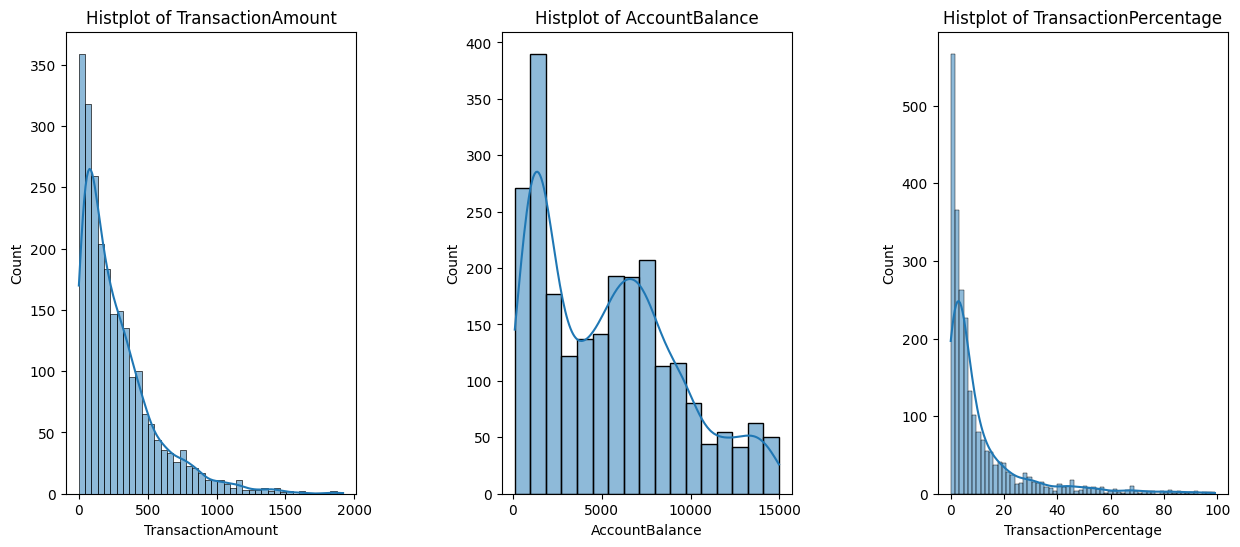

In [ ]:
plt.figure(1 , figsize = (15 , 6))
n = 0
for x in ['TransactionAmount' , 'AccountBalance' , 'TransactionPercentage']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.5)
    sns.histplot(data[x], kde=True)
    plt.title('Histplot of {}'.format(x))
plt.show()

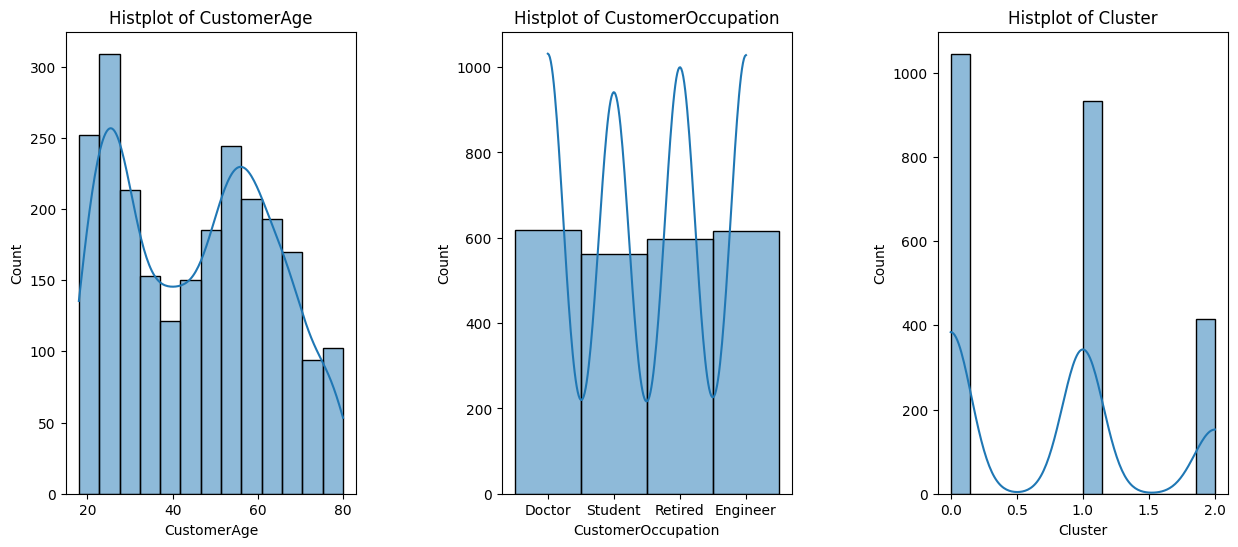

In [ ]:
plt.figure(1 , figsize = (15 , 6))
n = 0
for i in ['CustomerAge' , 'CustomerOccupation' , 'Cluster']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.5)
    sns.histplot(data[i], kde=True)
    plt.title('Histplot of {}'.format(i))
plt.show()

# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [6]:
mmscaler = MinMaxScaler()
stdscaler = StandardScaler()
data['CustomerAge'] = mmscaler.fit_transform(data[['CustomerAge']])
data[['TransactionAmount', 'AccountBalance']] = stdscaler.fit_transform(data[['TransactionAmount', 'AccountBalance']])
data.head()

,TransactionAmount,CustomerAge,AccountBalance,TransactionPercentage,CustomerOccupation_encoded,Cluster,PC1,PC2,CustomerOccupation
0,-0.968683,0.838710,-0.061074,0.275615,0,1,-236.169038,-262.693193,Doctor
1,0.362547,0.806452,2.185248,2.734519,0,2,8411.978360,62.603724,Doctor
2,-0.556246,0.016129,-1.097598,11.252283,3,0,-4225.586003,-133.316590,Student
3,-0.342271,0.129032,0.836979,2.153095,3,1,3221.311141,-107.053160,Student
4,-0.971035,0.129032,0.540908,0.181037,3,1,2080.931495,-273.239676,Student


In [10]:
X = data.drop(columns=["Cluster", "CustomerOccupation"])
y = data["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Ukuran train set: {X_train.shape}")
print(f"Ukuran test set: {X_test.shape}")

Ukuran train set: (1675, 7)
Ukuran test set: (718, 7)


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

- K-Nearest Neighbor (KNN) classifier

In [11]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.9916434540389972

- Decision Tree Classifier

In [12]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt.score(X_test, y_test)

1.0

- Support Vector Machine Classifier

In [13]:
svm = SVC()
svm.fit(X_train, y_train)
svm.score(X_test, y_test)

0.9944289693593314

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [14]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro')
    }
    return results

# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    print(f"K-Nearest Neighbors (KNN): {evaluate_model(knn, X_test, y_test)}"),
    print(f"Decision Tree : {evaluate_model(dt, X_test, y_test)}"),
    print(f"Support Vector Machine (SVM)': {evaluate_model(svm, X_test, y_test)}")
}

K-Nearest Neighbors (KNN): {'Accuracy': 0.9916434540389972, 'Precision': 0.9932020788285726, 'Recall': 0.9902356213311619, 'F1-Score': 0.9916940697200385}
Decision Tree : {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1-Score': 1.0}
Support Vector Machine (SVM)': {'Accuracy': 0.9944289693593314, 'Precision': 0.9954337899543378, 'Recall': 0.9895013123359581, 'F1-Score': 0.9923678160919541}


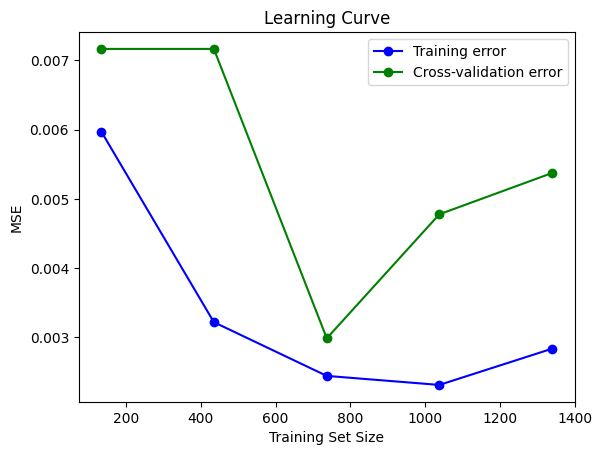

K-Nearest Neighbors (KNN): None


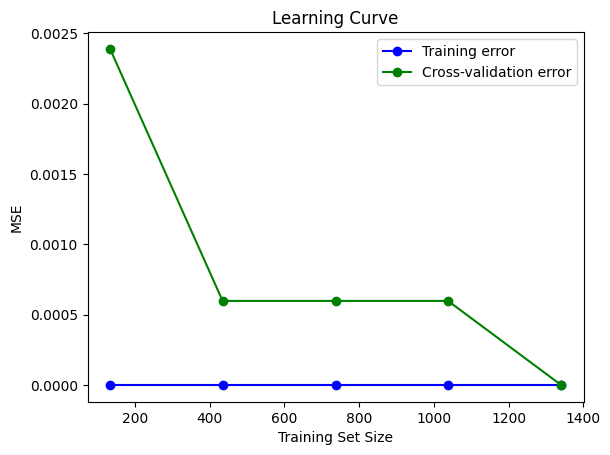

Decision Tree : None


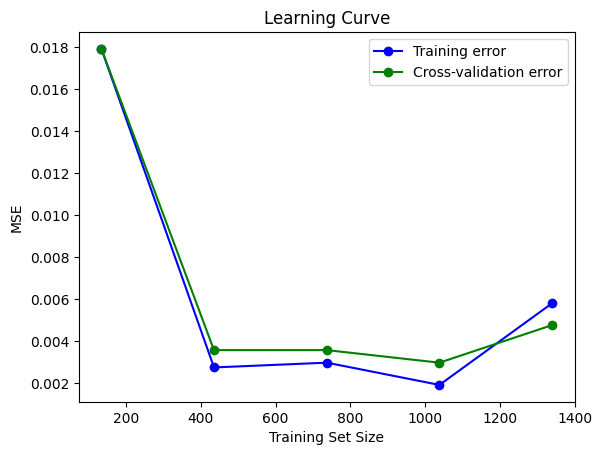

Support Vector Machine (SVM)': None


In [15]:
def learn_crv(model, X_test, y_test):
    train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

    train_mean = -np.mean(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training error")
    plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation error")
    plt.title("Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    print(f"K-Nearest Neighbors (KNN): {learn_crv(knn, X_test, y_test)}"),
    print(f"Decision Tree : {learn_crv(dt, X_test, y_test)}"),
    print(f"Support Vector Machine (SVM)': {learn_crv(svm, X_test, y_test)}")
}

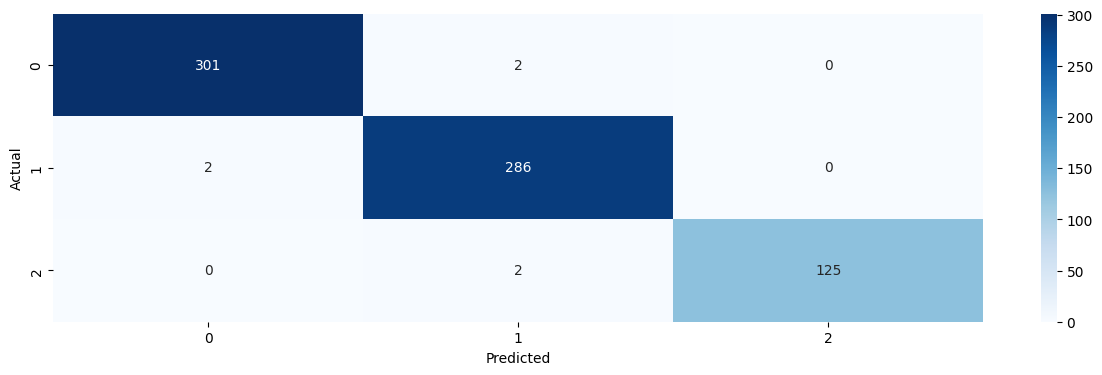

K-Nearest Neighbors (KNN): None


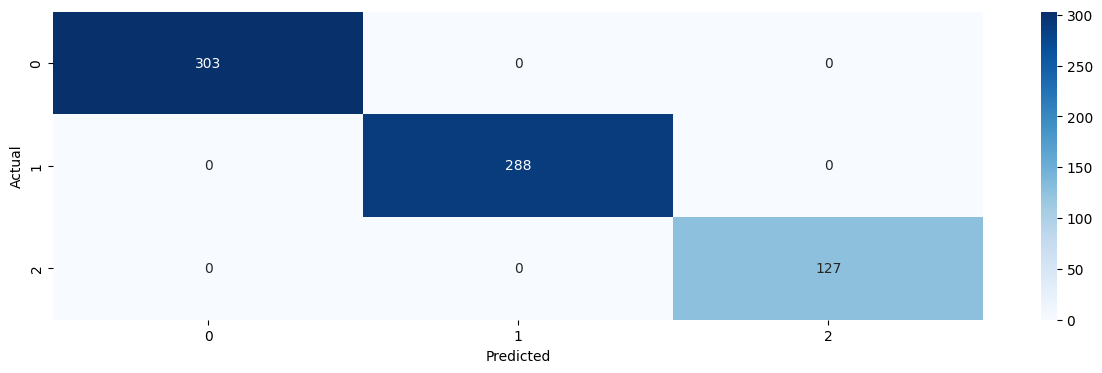

Decision Tree : None


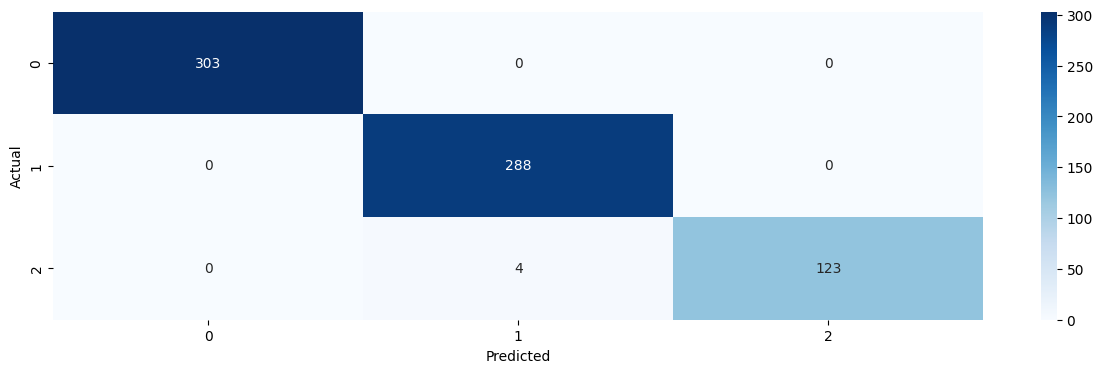

Support Vector Machine (SVM)': None


In [16]:
def plot_matrix(model, X_test, y_test):
    cm = confusion_matrix(y_test, model.predict(X_test))
    plt.figure (figsize = (15,4))
    sns.heatmap(cm, annot=True, cmap = 'Blues', fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    print(f"K-Nearest Neighbors (KNN): {plot_matrix(knn, X_test, y_test)}"),
    print(f"Decision Tree : {plot_matrix(dt, X_test, y_test)}"),
    print(f"Support Vector Machine (SVM)': {plot_matrix(svm, X_test, y_test)}")
}

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.

1. Model yang digunakan adalah KNN, Decision Tree, dan SVM. Ketiganya menunjukkan performa yang sangat baik. Hal ini dibuktikan oleh nilai Akurasi dan Presisi pada model KNN dan SVM yang mencapai 99%, bahkan mencapai 100% pada model Decision Tree.
Ini menandakan bahwa ketiga model mampu dengan tepat memprediksi cluster dari tiap data parameter, dengan kesalahan minimal.

2. Tidak ada kelemahan yang terlalu signifikan pada tiap model, kecuali pada error yang terlihat pada grafik Learning Rate.
- Untuk model Decision Tree, seiring meningkatnya ukuran data, angka error semakin menurun. Perilaku ini normal dan menandakan bahwa model bekerja dengan sempurna.
- Untuk model KNN, seiring meningkatnya ukuran data, angka error juga kian menurun. Kecuali ketika ukuran data melebihi 800, angka error naik. Meskipun pada grafik nampaknya cukup signifikan, nyatanya angka error hanya naik sekitar 0.2%, sehingga tidak signifikan sama sekali
- Untuk model SVM, perilaku yang mirip dengan model KNN juga terlihat. Bedanya, angka error naik ketika ukuran data melebihi 1000 data, dan angka error pada training data melebihi angka error pada testing/validation data.

3. Rekomendasi tindak lanjut:
- Pengumpulan data tambahan bisa dilakukan untuk membuktikan apakah model memang sesempurna yang ada pada notebook ini. Karena, data yang digunakan saat ini hanya terdiri dari 2393 baris, dimana jumlah ini relatif kecil.
- Karena algoritma yang digunakan saat ini adalah algoritma yang cocok untuk dataset berukuran kecil, maka algoritma lain bisa digunakan untuk melihat apakah performanya bisa sesempurna algoritma yang digunakan pada notebook ini.